## Classifying Data with Logistic Regression in Python 

### Part I:  Collect the data

In [1]:
import pandas as pd
import os

# Tüm dosyaları listele
print("Files:")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(f"- {filename}")


churn = pd.read_csv('/kaggle/input/customer-churn-dataset/customer_churn_dataset-training-master.csv')



Files:
- customer_churn_dataset-testing-master.csv
- customer_churn_dataset-training-master.csv


In [2]:
churn.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [3]:
churn.shape

(440833, 12)

### Part II: Explore the data

In [4]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [5]:
churn.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
print("How many NaN are there in:", churn['Churn'].isna().sum())

How many NaN are there in: 1


In [7]:
initial_rows = len(churn)


churn.dropna(subset=['Age', 'Usage Frequency', 'Payment Delay', 'Support Calls',
                        'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'], 
                inplace=True)

final_rows = len(churn)
print(f"Initial: {initial_rows}, Final: {final_rows}, number of drop: {initial_rows - final_rows}")

Initial: 440833, Final: 440832, number of drop: 1


### Data visualization 

In [8]:
from matplotlib import pyplot as plt
import seaborn as sns

<Axes: xlabel='Churn', ylabel='Age'>

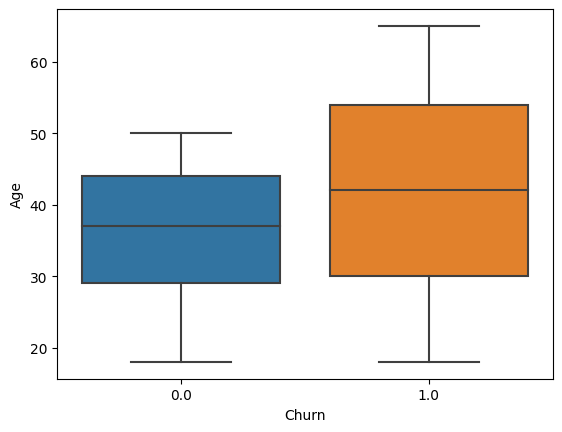

In [9]:
sns.boxplot(data = churn, x = 'Churn', y = 'Age')

<Axes: xlabel='Churn', ylabel='Payment Delay'>

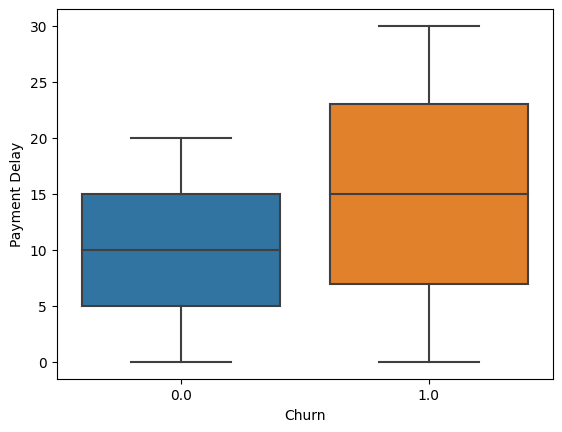

In [10]:
sns.boxplot(data = churn, x = 'Churn', y = 'Payment Delay')

<Axes: xlabel='Churn', ylabel='Support Calls'>

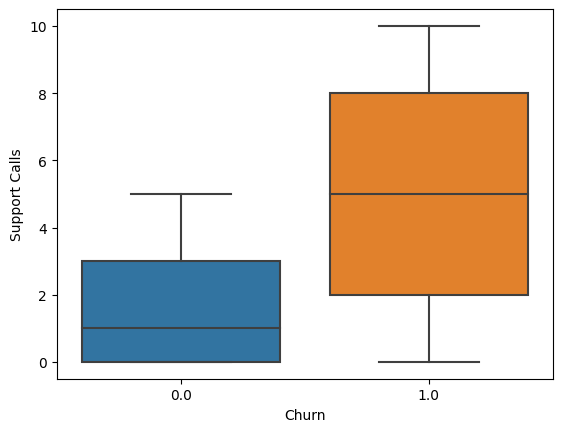

In [11]:
sns.boxplot(data = churn, x = 'Churn', y = 'Support Calls')

<Axes: xlabel='Churn', ylabel='Gender_numeric'>

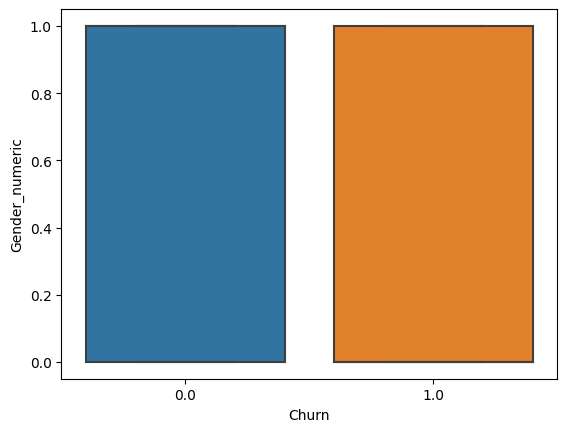

In [12]:
churn['Gender_numeric'] = churn['Gender'].map({'Female': 0, 'Male': 1})

# Boxplot
sns.boxplot(data=churn, x='Churn', y='Gender_numeric')

<Axes: xlabel='Churn', ylabel='Total Spend'>

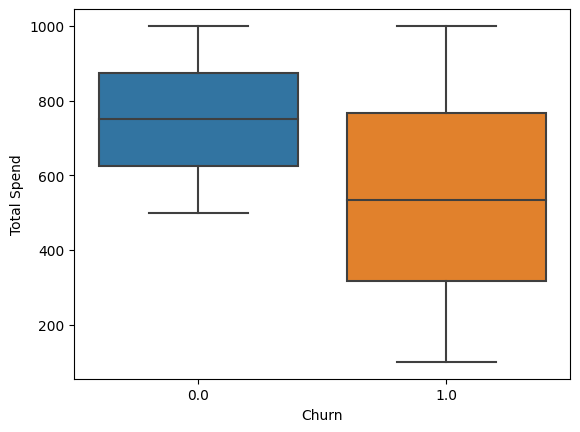

In [13]:
sns.boxplot(x='Churn', y='Total Spend', data=churn)

<Axes: xlabel='Age', ylabel='Churn'>

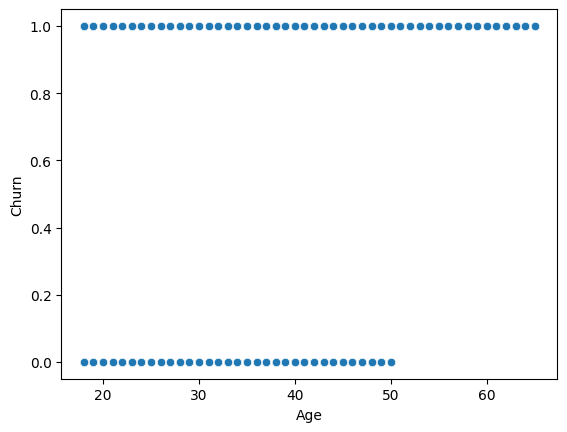

In [14]:
sns.scatterplot(x = churn['Age'], y = churn['Churn'])

<Axes: xlabel='Support Calls', ylabel='Churn'>

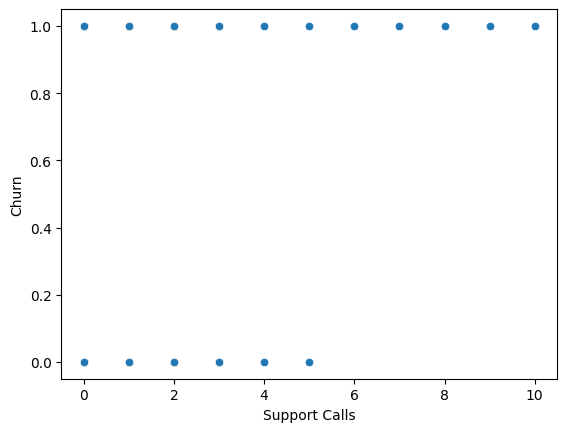

In [15]:
sns.scatterplot(x = churn['Support Calls'], y = churn['Churn'])

### Part III: Prepare the data

In [16]:
y = churn['Churn']

In [17]:
X = churn[['Age','Usage Frequency', 'Payment Delay','Support Calls','Contract Length', 'Total Spend','Last Interaction']]
X = pd.get_dummies(X, columns=['Contract Length'], drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, stratify = y, random_state = 42)

In [19]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (352665, 8)
X_test shape : (88167, 8)


### Part IV: Train and Evaluate the Model

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
print("CROSS-VALIDATION (scaled data):")

from sklearn.model_selection import cross_val_score
classifier = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(
    classifier,
    X_train_scaled, 
    y_train,
    cv=5,
    scoring='accuracy'
)

print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Std: {cv_scores.std():.4f}")


CROSS-VALIDATION (scaled data):
Mean CV accuracy: 0.8902
Std: 0.0015


In [23]:
classifier = LogisticRegression(max_iter=1000, class_weight='balanced')
model = classifier.fit(X_train_scaled, y_train)

In [24]:
y_pred_internal = model.predict(X_test_scaled) 
internal_accuracy = model.score(X_test_scaled, y_test)
print(f"Internal Test Accuracy (Scaled): {internal_accuracy:.4f}")

Internal Test Accuracy (Scaled): 0.8893


In [25]:
from sklearn.metrics import confusion_matrix

In [26]:
cm = confusion_matrix(y_test, y_pred_internal)
print(cm)

[[35282  2885]
 [ 6873 43127]]


Text(0.5, 1.0, 'Confusion Matrix – Test Set Performance')

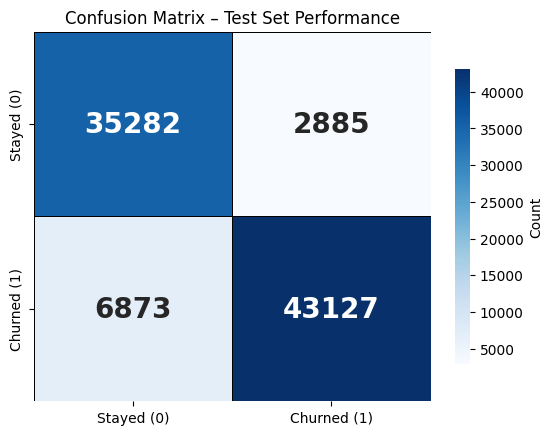

In [27]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            linewidths=0.7,
            linecolor='black',
            xticklabels=['Stayed (0)', 'Churned (1)'],
            yticklabels=['Stayed (0)', 'Churned (1)'],
            cbar_kws={'label': 'Count', 'shrink': 0.8},
            annot_kws={'size': 20, 'weight': 'bold'})
plt.title('Confusion Matrix – Test Set Performance')

### Part V: Interpret the Model

In [28]:
model.intercept_ # beta_0

array([2.66758011])

In [29]:
model.coef_ # beta_1, beta_2, beta_3.. coefficients

array([[ 4.22193410e-01, -1.20719000e-01,  9.24509962e-01,
         2.31301112e+00, -1.47116749e+00,  3.65811433e-01,
         4.71841639e+00, -4.19169807e-03]])

In [30]:
import numpy as np

log_odds = np.round(model.coef_[0],4)
log_odds

array([ 4.2220e-01, -1.2070e-01,  9.2450e-01,  2.3130e+00, -1.4712e+00,
        3.6580e-01,  4.7184e+00, -4.2000e-03])

In [31]:
pd.DataFrame({'log odds': log_odds}, index = X.columns)

,log odds
Age,0.4222
Usage Frequency,-0.1207
Payment Delay,0.9245
Support Calls,2.3130
Total Spend,-1.4712
Last Interaction,0.3658
Contract Length_Monthly,4.7184
Contract Length_Quarterly,-0.0042


In [32]:
odds = np.round(np.exp(log_odds),4)
pd.DataFrame({'odds': odds}, index = X.columns)

,odds
Age,1.5253
Usage Frequency,0.8863
Payment Delay,2.5206
Support Calls,10.1047
Total Spend,0.2296
Last Interaction,1.4417
Contract Length_Monthly,111.9889
Contract Length_Quarterly,0.9958


In [33]:
# PART VI: FINAL TEST SET SCORE

# Load test data
test_df = pd.read_csv('/kaggle/input/customer-churn-dataset/customer_churn_dataset-testing-master.csv')
print("Raw test data rows:", len(test_df))

# Clean like training data
test_df.dropna(subset=['Age', 'Usage Frequency', 'Payment Delay', 'Support Calls',
                       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'], 
               inplace=True)
test_df['Churn'] = test_df['Churn'].astype(int)
print("Cleaned test data rows:", len(test_df))

# Prepare features EXACTLY like training
X_real_test = test_df[['Age', 'Usage Frequency', 'Payment Delay', 'Support Calls',
                       'Contract Length', 'Total Spend', 'Last Interaction']]

# Apply same one-hot encoding
X_real_test = pd.get_dummies(X_real_test, columns=['Contract Length'], drop_first=True)

# Save original column names BEFORE scaling
original_columns = list(X.columns)  # X = original training features

# Make sure test columns match
missing_cols = set(original_columns) - set(X_real_test.columns)
for col in missing_cols:
    X_real_test[col] = 0

# Reorder columns
X_real_test = X_real_test[original_columns]

y_real_test = test_df['Churn']

# Scale using the SAME scaler
X_real_test_scaled = scaler.transform(X_real_test)  # NOT fit_transform!

# Final score
final_accuracy = model.score(X_real_test_scaled, y_real_test)
final_preds = model.predict(X_real_test_scaled)

print("\n" + "="*50)
print("REAL TEST SET RESULTS")
print("="*50)
print(f"Accuracy       : {final_accuracy:.5f}  →  {final_accuracy*100:.2f}%")
print(f"Total test rows: {len(test_df):,}")
print("="*50)

from sklearn.metrics import classification_report
print(classification_report(y_real_test, final_preds))

Raw test data rows: 64374
Cleaned test data rows: 64374

REAL TEST SET RESULTS
Accuracy       : 0.58424  →  58.42%
Total test rows: 64,374
              precision    recall  f1-score   support

           0       0.95      0.22      0.36     33881
           1       0.53      0.99      0.69     30493

    accuracy                           0.58     64374
   macro avg       0.74      0.60      0.53     64374
weighted avg       0.75      0.58      0.52     64374



In [34]:
test_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [35]:
print("TRAINING STATS:")
print(churn.describe())

print("\nTEST STATS:")
print(test_df.describe())

# Önemli feature'ların dağılımı
for col in ['Age', 'Payment Delay', 'Support Calls', 'Total Spend']:
    print(f"\n{col}:")
    print(f"Train mean: {churn[col].mean():.2f}, Test mean: {test_df[col].mean():.2f}")
    print(f"Train std:  {churn[col].std():.2f}, Test std:  {test_df[col].std():.2f}")

TRAINING STATS:
          CustomerID            Age         Tenure  Usage Frequency  \
count  440832.000000  440832.000000  440832.000000    440832.000000   
mean   225398.667955      39.373153      31.256336        15.807494   
std    129531.918550      12.442369      17.255727         8.586242   
min         2.000000      18.000000       1.000000         1.000000   
25%    113621.750000      29.000000      16.000000         9.000000   
50%    226125.500000      39.000000      32.000000        16.000000   
75%    337739.250000      48.000000      46.000000        23.000000   
max    449999.000000      65.000000      60.000000        30.000000   

       Support Calls  Payment Delay    Total Spend  Last Interaction  \
count  440832.000000  440832.000000  440832.000000     440832.000000   
mean        3.604437      12.965722     631.616223         14.480868   
std         3.070218       8.258063     240.803001          8.596208   
min         0.000000       0.000000     100.000000      

In [36]:
from sklearn.metrics import classification_report, confusion_matrix

# *** Düzeltme: Tahmin yaparken X_real_test_scaled kullanın ***
y_pred_real_test = model.predict(X_real_test_scaled) 


print(classification_report(y_real_test, y_pred_real_test))

print("\nConfusion Matrix (test seti):")
cm_test = confusion_matrix(y_real_test, y_pred_real_test)
print(cm_test)

              precision    recall  f1-score   support

           0       0.95      0.22      0.36     33881
           1       0.53      0.99      0.69     30493

    accuracy                           0.58     64374
   macro avg       0.74      0.60      0.53     64374
weighted avg       0.75      0.58      0.52     64374


Confusion Matrix (test seti):
[[ 7518 26363]
 [  401 30092]]


In [37]:
# QUICK DATA DRIFT ANALYSIS

import pandas as pd
import numpy as np
from scipy import stats

# 1. BASIC STATISTICS

print("FEATURE STATISTICS: Train vs Test")

feature_cols = ['Age', 'Usage Frequency', 'Payment Delay', 'Support Calls',
                'Total Spend', 'Last Interaction']

for col in feature_cols:
    print(f"\n{col}:")
    print(f"  Train → Mean: {churn[col].mean():.2f}, Std: {churn[col].std():.2f}")
    print(f"  Test  → Mean: {test_df[col].mean():.2f}, Std: {test_df[col].std():.2f}")
    
    # KS Test
    ks_stat, p_value = stats.ks_2samp(churn[col], test_df[col])
    
    if p_value < 0.05:
        print(f"  🚨 KS p-value: {p_value:.6f} → DISTRIBUTIONS DIFFERENT!")
    else:
        print(f"  ✅ KS p-value: {p_value:.6f} → Similar")


# 2. CHURN RATE COMPARISON

print("\n" + "="*50)
print("CHURN RATE COMPARISON")
print("="*50)


train_churn = churn['Churn'].mean()
test_churn = test_df['Churn'].mean()

print(f"Train Churn Rate: {train_churn:.4f} ({train_churn*100:.2f}%)")
print(f"Test Churn Rate : {test_churn:.4f} ({test_churn*100:.2f}%)")
print(f"Difference      : {abs(train_churn - test_churn):.4f} ({abs(train_churn - test_churn)*100:.2f}%)")

if abs(train_churn - test_churn) > 0.05:
    print("🚨 TARGET DISTRIBUTION VERY DIFFERENT!")
else:
    print("✅ Target distribution similar")


# 3. PSI (Population Stability Index) - Simple Version

print("\n" + "="*50)
print("📈 PSI (Population Stability Index)")
print("="*50)

print("PSI < 0.1  → ✅ No problem")
print("0.10 ≤ PSI < 0.20 → ⚠️  Medium drift")
print("0.20 ≤ PSI < 0.25  → 🚨 Serious drift!")
print("PSI ≥ 0.25 → 🚨🚨 Critical")
print("="*50)


def calculate_psi(expected, actual, bins=10):
    """Simple PSI calculation"""
    expected = expected.dropna()
    actual = actual.dropna()
    
    # Determine bins by quantiles
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)  # Remove duplicates
    
    if len(breakpoints) < 2:
        return 0.0
    
    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]
    
    # Normalize
    expected_percents = expected_counts / len(expected)
    actual_percents = actual_counts / len(actual)
    
    # Prevent zeros
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)
    
    # Calculate PSI
    psi = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    
    return psi

for col in feature_cols:
    psi = calculate_psi(churn[col], test_df[col])
    
    if psi < 0.1:
        status = "✅"
    elif 0.10 <= psi < 0.20:
        status = "⚠️"
    elif 0.20 <= psi < 0.25:
        status ="🚨"
    else:
        status = "🚨🚨"
    
    print(f"{status} {col:25s}: PSI = {psi:.4f}")


# 4. CONTRACT LENGTH COMPARISON

print("\n" + "="*50)
print("📋 CONTRACT LENGTH DISTRIBUTION")
print("="*50)


print("\nTrain:")
print(churn['Contract Length'].value_counts(normalize=True).sort_index())

print("\nTest:")
print(test_df['Contract Length'].value_counts(normalize=True).sort_index())

FEATURE STATISTICS: Train vs Test

Age:
  Train → Mean: 39.37, Std: 12.44
  Test  → Mean: 41.97, Std: 13.92
  🚨 KS p-value: 0.000000 → DISTRIBUTIONS DIFFERENT!

Usage Frequency:
  Train → Mean: 15.81, Std: 8.59
  Test  → Mean: 15.08, Std: 8.82
  🚨 KS p-value: 0.000000 → DISTRIBUTIONS DIFFERENT!

Payment Delay:
  Train → Mean: 12.97, Std: 8.26
  Test  → Mean: 17.13, Std: 8.85
  🚨 KS p-value: 0.000000 → DISTRIBUTIONS DIFFERENT!

Support Calls:
  Train → Mean: 3.60, Std: 3.07
  Test  → Mean: 5.40, Std: 3.11
  🚨 KS p-value: 0.000000 → DISTRIBUTIONS DIFFERENT!

Total Spend:
  Train → Mean: 631.62, Std: 240.80
  Test  → Mean: 541.02, Std: 260.87
  🚨 KS p-value: 0.000000 → DISTRIBUTIONS DIFFERENT!

Last Interaction:
  Train → Mean: 14.48, Std: 8.60
  Test  → Mean: 15.50, Std: 8.64
  🚨 KS p-value: 0.000000 → DISTRIBUTIONS DIFFERENT!

CHURN RATE COMPARISON
Train Churn Rate: 0.5671 (56.71%)
Test Churn Rate : 0.4737 (47.37%)
Difference      : 0.0934 (9.34%)
🚨 TARGET DISTRIBUTION VERY DIFFERENT!

